In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset.csv")
df.head()

,EmployeeID,Age,Department,DistanceFromHome,JobRole,MonthlyIncome,OverTime,YearsAtCompany,JobSatisfaction,WorkLifeBalance,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear,Attrition,PerformanceRating
0,E001,35,Sales,5,Sales Executive,5000,Yes,8,4,3,2,10,2,Yes,3
1,E002,40,Research & Development,10,Research Scientist,6000,No,15,3,2,1,20,3,No,4
2,E003,29,Human Resources,2,Human Resources,3500,Yes,3,1,1,3,5,1,Yes,2
3,E004,,Sales,8,Sales Representative,4200,No,6,4,3,0,8,2,No,3
4,E005,45,Research & Development,15,Laboratory Technician,5500,Yes,12,2,2,4,25,4,Yes,3


In [60]:
df.shape

(2200, 15)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   EmployeeID             2200 non-null   object
 1   Age                    2200 non-null   object
 2   Department             2200 non-null   object
 3   DistanceFromHome       2200 non-null   int64 
 4   JobRole                2200 non-null   object
 5   MonthlyIncome          2200 non-null   int64 
 6   OverTime               2200 non-null   object
 7   YearsAtCompany         2200 non-null   int64 
 8   JobSatisfaction        2200 non-null   int64 
 9   WorkLifeBalance        2200 non-null   int64 
 10  NumCompaniesWorked     2200 non-null   int64 
 11  TotalWorkingYears      2200 non-null   int64 
 12  TrainingTimesLastYear  2200 non-null   int64 
 13  Attrition              2200 non-null   object
 14  PerformanceRating      2200 non-null   int64 
dtypes: int64(9), object(6

In [62]:
df["Attrition"].value_counts()

No     1568
Yes     632
Name: Attrition, dtype: int64

In [63]:
df.describe()

,DistanceFromHome,MonthlyIncome,YearsAtCompany,JobSatisfaction,WorkLifeBalance,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear,PerformanceRating
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,8.184091,6173.431818,13.008636,2.903636,2.650455,2.111818,16.711818,2.781818,3.291818
std,5.136891,2253.644372,8.128930,1.048954,0.928602,1.168499,9.718533,1.082599,0.672548
min,1.000000,2800.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,2.000000
25%,4.000000,4400.000000,6.000000,2.000000,2.000000,1.000000,8.000000,2.000000,3.000000
50%,7.000000,5600.000000,11.000000,3.000000,3.000000,2.000000,15.000000,3.000000,3.000000
75%,12.000000,7700.000000,20.000000,4.000000,3.000000,3.000000,25.000000,3.000000,4.000000
max,25.000000,12000.000000,34.000000,4.000000,4.000000,5.000000,38.000000,5.000000,4.000000


In [64]:
df.dtypes
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df["Age"] = df['Age'].fillna(df["Age"].median())

df['Department'] = df['Department'].fillna('Unknown')
df['MonthlyIncome'] = df['MonthlyIncome'].astype(str).str.strip().astype(float)
df.isnull().sum()

EmployeeID               0
Age                      0
Department               0
DistanceFromHome         0
JobRole                  0
MonthlyIncome            0
OverTime                 0
YearsAtCompany           0
JobSatisfaction          0
WorkLifeBalance          0
NumCompaniesWorked       0
TotalWorkingYears        0
TrainingTimesLastYear    0
Attrition                0
PerformanceRating        0
dtype: int64

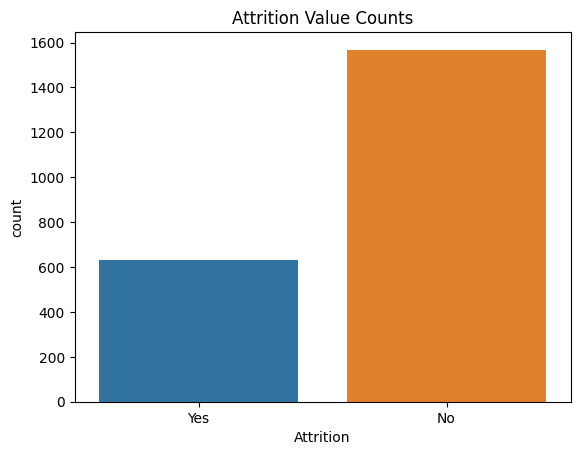

In [65]:
sns.countplot(x="Attrition",data=df)
plt.title("Attrition Value Counts")
plt.show()

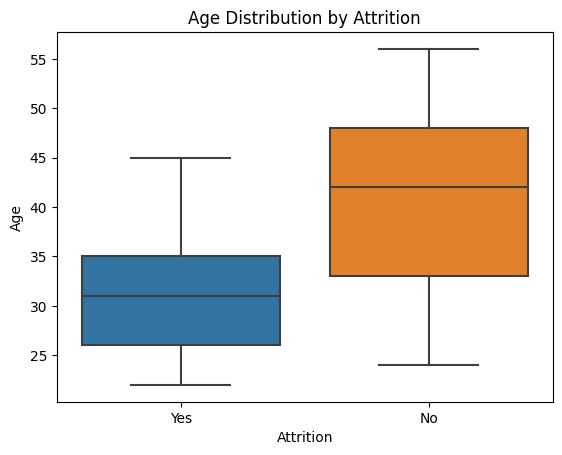

In [66]:
sns.boxplot(x='Attrition', y='Age', data=df)
plt.title('Age Distribution by Attrition')
plt.show()

In [67]:
df.dtypes

EmployeeID                object
Age                      float64
Department                object
DistanceFromHome           int64
JobRole                   object
MonthlyIncome            float64
OverTime                  object
YearsAtCompany             int64
JobSatisfaction            int64
WorkLifeBalance            int64
NumCompaniesWorked         int64
TotalWorkingYears          int64
TrainingTimesLastYear      int64
Attrition                 object
PerformanceRating          int64
dtype: object

In [68]:
df["IncomePerYear"] = (df["MonthlyIncome"] / (df["YearsAtCompany"] + 1))

df = df.drop(["EmployeeID"],axis=1)
df.head()

,Age,Department,DistanceFromHome,JobRole,MonthlyIncome,OverTime,YearsAtCompany,JobSatisfaction,WorkLifeBalance,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear,Attrition,PerformanceRating,IncomePerYear
0,35.0,Sales,5,Sales Executive,5000.0,Yes,8,4,3,2,10,2,Yes,3,555.555556
1,40.0,Research & Development,10,Research Scientist,6000.0,No,15,3,2,1,20,3,No,4,375.000000
2,29.0,Human Resources,2,Human Resources,3500.0,Yes,3,1,1,3,5,1,Yes,2,875.000000
3,37.0,Sales,8,Sales Representative,4200.0,No,6,4,3,0,8,2,No,3,600.000000
4,45.0,Research & Development,15,Laboratory Technician,5500.0,Yes,12,2,2,4,25,4,Yes,3,423.076923


In [69]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


In [70]:
X = df.drop(["Attrition"], axis=1)
y = df["Attrition"]

le = LabelEncoder()
y = le.fit_transform(y)

In [71]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()

In [72]:
prep = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown='ignore', sparse=False), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)

In [73]:
model_pipe = Pipeline(steps=[
    ("preprocessing", prep),
    ("clmodel", RandomForestClassifier(n_estimators=100, random_state=42))
])

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False),
                                                  ['Department', 'JobRole',
                                                   'OverTime']),
                                                 ('num', StandardScaler(),
                                                  ['Age', 'DistanceFromHome',
                                                   'MonthlyIncome',
                                                   'YearsAtCompany',
                                                   'JobSatisfaction',
                                                   'WorkLifeBalance',
                                                   'NumCompaniesWorked',
                                                   'TotalWorkingYears',
                         

In [75]:
y_pred = model_pipe.predict(X_test)

In [76]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [77]:
print("ACCURACY SCORE :", accuracy_score(y_test, y_pred))
print("Classification Report :", classification_report(y_test, y_pred))
print("Confusion Matrix :", confusion_matrix(y_test, y_pred))
print("ROC AUC SCORE :", roc_auc_score(y_test, y_pred))

ACCURACY SCORE : 0.9863636363636363
Classification Report :               precision    recall  f1-score   support

           0       0.99      0.99      0.99       308
           1       0.97      0.98      0.98       132

    accuracy                           0.99       440
   macro avg       0.98      0.99      0.98       440
weighted avg       0.99      0.99      0.99       440

Confusion Matrix : [[304   4]
 [  2 130]]
ROC AUC SCORE : 0.985930735930736


In [85]:
new_data = {
    "Age": 30,
    "Department": "Sales",
    "DistanceFromHome": 10,
    "JobRole": "Sales Executive",
    "MonthlyIncome": 4000,
    "OverTime": "Yes",
    "YearsAtCompany": 5,
    "JobSatisfaction": 3,
    "WorkLifeBalance": 2,
    "NumCompaniesWorked": 1,
    "TotalWorkingYears": 8,
    "TrainingTimesLastYear": 2,
    "PerformanceRating": 3,
    "IncomePerYear": 500
}
newdf = pd.DataFrame([new_data])
newdf

prediction = model_pipe.predict(newdf)
print(prediction)

if prediction[0] == 1:
    print("Employee is likely to LEAVE")
else:
    print("Employee is likely to STAY")

[1]
Employee is likely to LEAVE


In [88]:
probs = model_pipe.predict_proba(newdf)
print(probs)
leave_prob = probs[0][1]
print(f"Probability of leaving: {leave_prob * 100:.2f}%")

[[0.21 0.79]]
Probability of leaving: 79.00%
